In [1]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [2]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


KeyError: 'label'

In [6]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Dataset Shape:", df.shape)


Dataset Shape: (5572, 2)


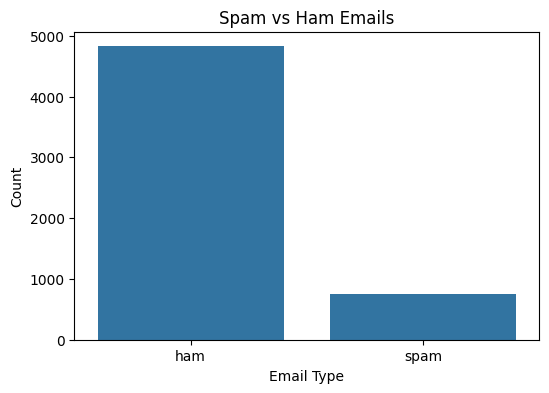

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [9]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

/tmp/ipykernel_1145/877984064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
X = df['text']

y = df['label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [12]:
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 4457
Testing Samples : 1115


In [13]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [14]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [15]:
y_pred = model.predict(X_test_tfidf)

In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9730941704035875


In [17]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 1.0


In [18]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.8


In [19]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.8888888888888888


In [20]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[965   0]
 [ 30 120]]


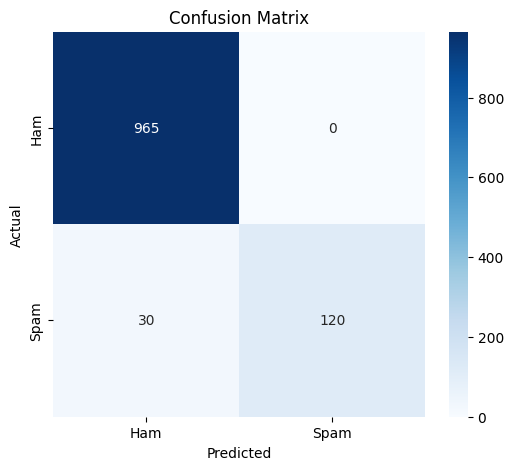

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

email_vector = tfidf.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Spam Email


In [24]:
email = [
    "Hi John, are we meeting tomorrow at 10 AM?"
]

email_vector = tfidf.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Ham Email


In [25]:
import joblib

joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF Vectorizer saved successfully!")

Model and TF-IDF Vectorizer saved successfully!
